In [3]:
%pip install "setuptools<70.0.0"

Note: you may need to restart the kernel to use updated packages.


In [2]:
# 1. FORCE TENSORFLOW TO USE KERAS 2
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

# 2. Import everything
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

print("TensorFlow Version: ", tf.__version__)
print("Hub version: ", hub.__version__)
print("Eager mode: ", tf.executing_eagerly())
print("Hub version: ", hub.__version__)
print("GPU is", "availible" if tf.config.list_physical_devices("GPU") else "NOT AVAILIBLE")

TensorFlow Version:  2.20.0
Hub version:  0.16.1
Eager mode:  True
Hub version:  0.16.1
GPU is NOT AVAILIBLE


In [3]:
%pip install importlib-resources


Note: you may need to restart the kernel to use updated packages.


In [4]:
import tensorflow_datasets as tfds

# The tfds.load command automatically downloads the dataset and splits it up.
# We are taking the 25,000 training examples and splitting them: 60% for training, 40% for validation.
# The 25,000 test examples are kept intact.
train_data, validation_data, test_data = tfds.load(
    name="imdb_reviews", 
    split=('train[:60%]', 'train[60%:]', 'test'),
    as_supervised=True
)

print("IMDB Dataset loaded successfully!")

IMDB Dataset loaded successfully!


In [5]:
train_data, test_data = tfds.load(name="imdb_reviews", split=["train", "test"], 
                                  batch_size=-1, as_supervised=True)

train_examples, train_labels = tfds.as_numpy(train_data)
test_examples, test_labels = tfds.as_numpy(test_data)

In [6]:
# 1. Unpack the dataset into 3 distinct variables
train_data, validation_data, test_data = tfds.load(
    name="imdb_reviews", 
    split=('train[:60%]', 'train[60%:]', 'test'),
    as_supervised=True
)

# 2. Grab the first 3 examples from the training data
for review, label in train_data.take(3):
    print("Review: ", review.numpy())
    print("Label: ", label.numpy())
    print("-" * 50)

Review:  b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it."
Label:  0
--------------------------------------------------
Review:  b'I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable on the sette and having just eaten a lot. However on thi

In [7]:
print("Training entries: {}, test entries: {}".format(len(train_examples), len(test_examples)))

Training entries: 25000, test entries: 25000


In [8]:
train_examples[:10]

array([b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it.",
       b'I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable on the sette and having just eaten a lot. However on this occasion I fell asleep because the film was rubbish. The plot 

In [9]:
train_labels[:10]

array([0, 0, 0, 1, 1, 1, 0, 0, 0, 0])

In [10]:
model = "https://tfhub.dev/google/nnlm-en-dim50/2"
hub_layer = hub.KerasLayer(model, input_shape=[], dtype=tf.string, trainable=True)
hub_layer(train_examples[:3])

<tf.Tensor: shape=(3, 50), dtype=float32, numpy=
array([[ 0.5423195 , -0.0119017 ,  0.06337538,  0.06862972, -0.16776837,
        -0.10581174,  0.16865303, -0.04998824, -0.31148055,  0.07910346,
         0.15442263,  0.01488662,  0.03930153,  0.19772711, -0.12215476,
        -0.04120981, -0.2704109 , -0.21922152,  0.26517662, -0.80739075,
         0.25833532, -0.3100421 ,  0.28683215,  0.1943387 , -0.29036492,
         0.03862849, -0.7844411 , -0.0479324 ,  0.4110299 , -0.36388892,
        -0.58034706,  0.30269456,  0.3630897 , -0.15227164, -0.44391504,
         0.19462997,  0.19528408,  0.05666234,  0.2890704 , -0.28468323,
        -0.00531206,  0.0571938 , -0.3201318 , -0.04418665, -0.08550783,
        -0.55847436, -0.23336391, -0.20782952, -0.03543064, -0.17533456],
       [ 0.56338924, -0.12339553, -0.10862679,  0.7753425 , -0.07667089,
        -0.15752277,  0.01872335, -0.08169781, -0.3521876 ,  0.4637341 ,
        -0.08492756,  0.07166859, -0.00670817,  0.12686075, -0.19326553,
 

In [11]:
model = tf.keras.Sequential()
model.add(hub_layer)
model.add(tf.keras.layers.Dense(16, activation='relu'))
model.add(tf.keras.layers.Dense(1))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer (KerasLayer)    (None, 50)                48190600  
                                                                 
 dense (Dense)               (None, 16)                816       
                                                                 
 dense_1 (Dense)             (None, 1)                 17        
                                                                 
Total params: 48191433 (183.84 MB)
Trainable params: 48191433 (183.84 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [15]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=[tf.keras.metrics.BinaryAccuracy(threshold=0.0, name='accuracy')])

print("Model configured and ready to learn!")

Model configured and ready to learn!


In [16]:
# We train for 10 "epochs" (meaning the AI will read through the entire homework pile 10 times)
history = model.fit(train_data.shuffle(10000).batch(512),
                    epochs=10,
                    validation_data=validation_data.batch(512),
                    verbose=1)

Epoch 1/10



30/30 [==============================] - 8s 206ms/step - loss: 0.6493 - accuracy: 0.6544 - val_loss: 0.5974 - val_accuracy: 0.7348
Epoch 2/10
30/30 [==============================] - 6s 188ms/step - loss: 0.5275 - accuracy: 0.7941 - val_loss: 0.4835 - val_accuracy: 0.8015
Epoch 3/10
30/30 [==============================] - 6s 190ms/step - loss: 0.3903 - accuracy: 0.8603 - val_loss: 0.3900 - val_accuracy: 0.8440
Epoch 4/10
30/30 [==============================] - 6s 191ms/step - loss: 0.2825 - accuracy: 0.9051 - val_loss: 0.3399 - val_accuracy: 0.8568
Epoch 5/10
30/30 [==============================] - 6s 198ms/step - loss: 0.2077 - accuracy: 0.9349 - val_loss: 0.3175 - val_accuracy: 0.8670
Epoch 6/10
30/30 [==============================] - 6s 192ms/step - loss: 0.1549 - accuracy: 0.9568 - val_loss: 0.3130 - val_accuracy: 0.8697
Epoch 7/10
30/30 [==============================] - 6s 187ms/step - loss: 0.1146 - accuracy: 0.9728 - val_loss: 0.3064 - val_accuracy: 0.8731
Epoch 8/10
30/30 

In [17]:
results = model.evaluate(test_examples, test_labels)

print(results)

782/782 [==============================] - 14s 18ms/step - loss: 0.3555 - accuracy: 0.8577
[0.3555294871330261, 0.8577200174331665]


In [18]:
# 1. Write your own custom reviews
my_reviews = [
    "This movie was an absolute masterpiece! I loved every second of it.",
    "Terrible acting, boring plot, and a complete waste of time.",
    "The special effects were amazing, but the story was incredibly predictable."
]

# 2. Convert the text to a TensorFlow-friendly format
custom_data = tf.constant(my_reviews)

# 3. Ask the AI to grade your custom reviews
predictions = model.predict(custom_data)

# 4. Print the results in a readable format
for i in range(len(my_reviews)):
    # Because we used from_logits=True earlier, the raw output is a math score.
    # tf.sigmoid squashes that raw math into a clean 0.0 to 1.0 probability!
    score = tf.sigmoid(predictions[i][0]).numpy()
    
    # If the score is above 50%, we call it positive
    sentiment = "POSITIVE" if score >= 0.5 else "NEGATIVE"
    
    print(f"Review: {my_reviews[i]}")
    print(f"AI Confidence: {score * 100:.2f}% Positive")
    print(f"Verdict: {sentiment}")
    print("-" * 50)

1/1 [==============================] - 0s 157ms/step
Review: This movie was an absolute masterpiece! I loved every second of it.
AI Confidence: 86.04% Positive
Verdict: POSITIVE
--------------------------------------------------
Review: Terrible acting, boring plot, and a complete waste of time.
AI Confidence: 1.26% Positive
Verdict: NEGATIVE
--------------------------------------------------
Review: The special effects were amazing, but the story was incredibly predictable.
AI Confidence: 9.37% Positive
Verdict: NEGATIVE
--------------------------------------------------


In [19]:
history_dict = history.history
history_dict.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

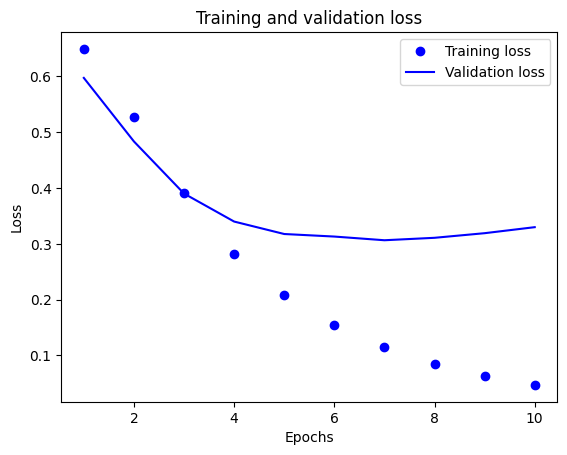

In [20]:
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


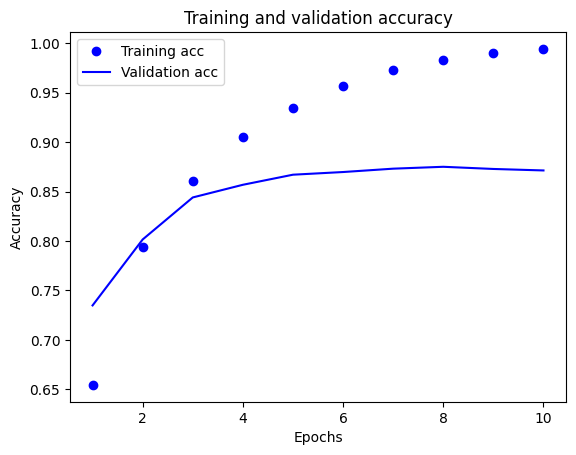

In [21]:
plt.clf()   # clear figure

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [22]:
# A new batch of tricky reviews to test the AI
more_reviews = [
    # 1. The Obvious Winner
    "An absolute joy to watch from start to finish. The cinematography is breathtaking and the acting is top-notch.",
    
    # 2. The Obvious Loser
    "I walked out of the theater after 30 minutes. The dialogue is cringeworthy and the plot makes absolutely no sense.",
    
    # 3. The "Slow Burn" (Starts bad, ends good)
    "It starts off a bit slow and the first act drags, but the explosive finale and emotional payoff make it completely worth your time.",
    
    # 4. Sarcasm (Will the AI understand sarcasm?)
    "Oh sure, if you love watching paint dry for three hours, this is the perfect movie for you. A total masterpiece of boredom.",
    
    # 5. The Horror Movie (Where "bad" emotions are actually praise)
    "This movie was absolutely terrifying and kept me on the edge of my seat. I couldn't sleep for days. Brilliant!"
]

# Convert and Predict
custom_data = tf.constant(more_reviews)
predictions = model.predict(custom_data)

# Print the results
for i in range(len(more_reviews)):
    score = tf.sigmoid(predictions[i][0]).numpy()
    sentiment = "POSITIVE" if score >= 0.5 else "NEGATIVE"
    
    print(f"Review: {more_reviews[i]}")
    print(f"AI Confidence: {score * 100:.2f}% Positive")
    print(f"Verdict: {sentiment}")
    print("-" * 50)

1/1 [==============================] - 0s 54ms/step
Review: An absolute joy to watch from start to finish. The cinematography is breathtaking and the acting is top-notch.
AI Confidence: 96.24% Positive
Verdict: POSITIVE
--------------------------------------------------
Review: I walked out of the theater after 30 minutes. The dialogue is cringeworthy and the plot makes absolutely no sense.
AI Confidence: 1.91% Positive
Verdict: NEGATIVE
--------------------------------------------------
Review: It starts off a bit slow and the first act drags, but the explosive finale and emotional payoff make it completely worth your time.
AI Confidence: 94.37% Positive
Verdict: POSITIVE
--------------------------------------------------
Review: Oh sure, if you love watching paint dry for three hours, this is the perfect movie for you. A total masterpiece of boredom.
AI Confidence: 47.87% Positive
Verdict: NEGATIVE
--------------------------------------------------
Review: This movie was absolutely t